# Taller: Introducción a Machine Learning

## 1. Introducción
El aprendizaje automático (**Machine Learning, ML**) es una rama de la inteligencia artificial que permite a las computadoras **aprender patrones a partir de datos** para realizar predicciones o clasificaciones sin ser programadas explícitamente.  
En este taller trabajaremos con un flujo completo de entrenamiento de un modelo clásico de ML: las **Máquinas de Vectores de Soporte (SVM, Support Vector Machines)**, ampliamente utilizadas en aplicaciones biomédicas por su capacidad de separar clases de manera robusta, incluso en espacios de alta dimensión.

El objetivo es que comprendas, paso a paso, cómo preparar los datos, entrenar un modelo, evaluar su rendimiento y visualizar los resultados. No solo aprenderás la teoría, sino que también **ejecutarás código práctico**, explorando cómo cambian los resultados al variar hiperparámetros o aumentar las iteraciones de entrenamiento.

## 2. Objetivos
1. **Carga y exploración de datos**: comprender la estructura y características principales del dataset.  
2. **División de datos (train/test)**: entender su importancia para evaluar la generalización del modelo.  
3. **Curvas de aprendizaje (SVM lineal)**: identificar problemas de sesgo y varianza.  
4. **Entrenamiento con SVM RBF**: aplicar un kernel no lineal y ajustar hiperparámetros.  
5. **Entrenamiento iterativo**: observar cómo mejora el desempeño con más épocas.  
6. **Evaluación del modelo**: interpretar métricas y una matriz de confusión.  
7. **Visualización en 2D con PCA**: proyectar los datos y observar las fronteras de decisión.  

## 3. Dataset


En este taller utilizaremos **MedMNIST**, una colección estandarizada de imágenes biomédicas en formato *MNIST-like*.  
Fue desarrollada para facilitar la investigación y la enseñanza en **análisis de imágenes médicas** y **machine learning**, ofreciendo un punto de partida ligero y accesible.

![](/Users/carlos/Documents/github/Talleres_Diplomado_iHealth/img/medmnist.png)


## 3.1 Cargar datos


En **MedMNIST**, los datasets se cargan fácilmente con su API oficial.  
Por ejemplo, para el caso de **PneumoniaMNIST**:

```python
from medmnist import PneumoniaMNIST

# Cargamos el set de entrenamiento
train_dataset = PneumoniaMNIST(split="train", download=True)

# Exploramos algunos elementos
for image, label in train_dataset:
    print(image.shape, label)
    break
```

### División de los datos

Al igual que en otros datasets de aprendizaje automático, los datos no se entregan como un único conjunto, sino divididos en particiones:
* Train (entrenamiento): datos que el modelo ve y utiliza para aprender los parámetros.
 * Test (prueba): datos reservados, que nunca se usan en el entrenamiento, y que sirven para medir la capacidad del modelo de generalizar a información nueva.
 * Validation (validación): en algunos casos (como PneumoniaMNIST), existe un tercer conjunto que se utiliza durante el desarrollo para ajustar hiperparámetros o comparar variantes del modelo sin tocar aún el test final.

¿Por qué es importante esta separación?
 * Evita sobreajuste (overfitting): si el modelo se evaluara únicamente en los datos de entrenamiento, obtendría métricas irreales, ya que estaría “memorizando” los ejemplos.
 * Permite elegir modelos: el conjunto de validación ayuda a decidir qué parámetros o configuraciones funcionan mejor antes de la evaluación final.
 * Asegura una medición justa: el conjunto de test funciona como un examen final, garantizando que el rendimiento reportado refleja la capacidad de generalización a nuevos datos.



In [177]:
from medmnist import PneumoniaMNIST

# Cargamos el set de entrenamiento
train_dataset = PneumoniaMNIST(split="train", download=True, size=28)
index_2_label = {0: 'normal', 1: 'pneumonia'}

## 3.2 Exploración de los datos

#### **Ejercicio 1** 

Visualiza algunas imágenes del set de training del dataset con sus etiquetas. Genera un plot de 5 x 5 utilizando Matplotlib. HINT: Utiliza subplots.



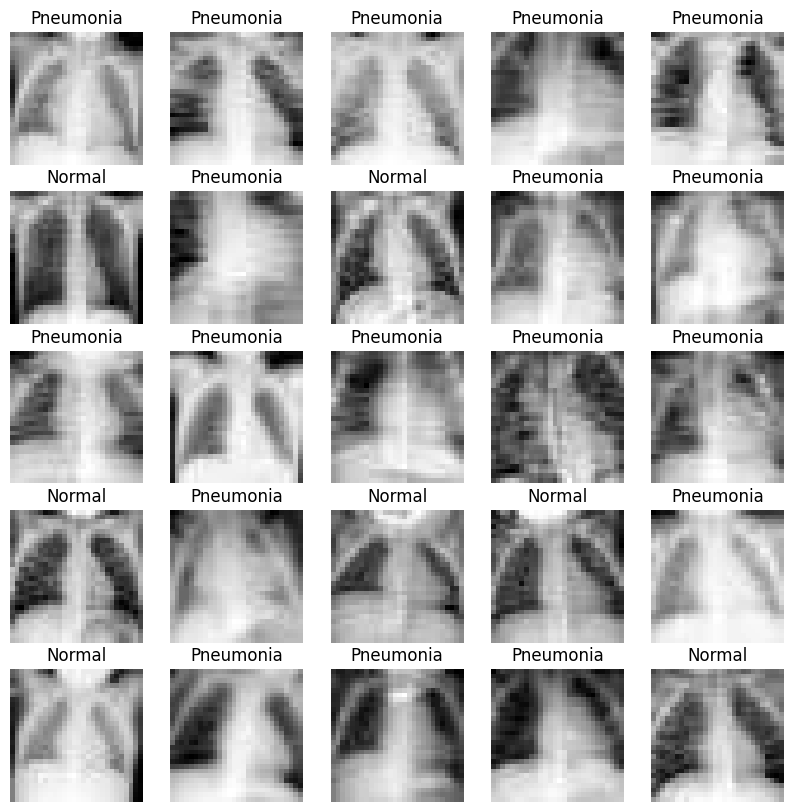

In [178]:
# <CODE>
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i, (imagen, label) in enumerate(train_dataset):
    ax = plt.subplot(5, 5, i + 1)
    plt.imshow(imagen, cmap='gray')
    plt.title(index_2_label[label[0]].capitalize())
    plt.axis("off")
    if i == 24:
        break
plt.show()


#### **Ejercicio 2** 

Ya que les hemos dado una mirada a las imagenes es importante entender su estructura y características. Responda:

* ¿Cual es es el tamaño de las imágenes?
* ¿Cuántas imágenes hay en el conjunto de entrenamiento?
* Cargue el conjunto de testing:
    * ¿Cuál es es el tamaño de las imágenes?
    * ¿Cuántas imágenes hay en el conjunto de testing?
* ¿Cuántas clases hay en el conjunto de datos?
* ¿Porque un set de datos es más grande que otro?


In [179]:
# <CODE>

# Tamaño de las imagenes
image, label = next(iter(train_dataset))
print(f"Imagen batch shape: {image.size}")

# Imagenes en el conjunto de entrenamiento
print(f"Numero de imagenes en el conjunto de entrenamiento: {len(train_dataset)}")

# Dataset de testing
test_dataset = PneumoniaMNIST(split="test", download=True, size=28)

# Tamaño de las imagenes
image, label = next(iter(test_dataset))
print(f"Imagen batch shape: {image.size}")

# Imagenes en el conjunto de testing
print(f"Numero de imagenes en el conjunto de testing: {len(test_dataset)}")

# Clases por grupo
print("")
print("Set de entrenamiento")
labels_training = [label[0] for _, label in train_dataset]
print("Numero de imagenes con neumonia:", labels_training.count(0))
print("Numero de imagenes sin neumonia:", labels_training.count(1))

print("Set de testing")
labels_testing = [label[0] for _, label in test_dataset]
print("Numero de imagenes con neumonia:", labels_testing.count(0))
print("Numero de imagenes sin neumonia:", labels_testing.count(1))


Imagen batch shape: (28, 28)
Numero de imagenes en el conjunto de entrenamiento: 4708
Imagen batch shape: (28, 28)
Numero de imagenes en el conjunto de testing: 624

Set de entrenamiento
Numero de imagenes con neumonia: 1214
Numero de imagenes sin neumonia: 3494
Set de testing
Numero de imagenes con neumonia: 234
Numero de imagenes sin neumonia: 390


## 4. Pipeline de entrenamiento

Un **pipeline de entrenamiento** es la secuencia de pasos que seguimos para preparar los datos, entrenar un modelo y evaluar su rendimiento.  
En el caso de **Support Vector Machines (SVM)**, el flujo suele incluir:

1. **Carga de datos:** obtener los ejemplos (imágenes, etiquetas).  
2. **División de datos:** separar en entrenamiento, validación y prueba.  
3. **Preprocesamiento:** aplanar o vectorizar imágenes, escalar variables para que todas tengan el mismo rango, y opcionalmente aplicar **PCA** para reducción de dimensionalidad.  
4. **Entrenamiento inicial:** ajustar un modelo SVM (lineal o con kernel).  
5. **Evaluación:** medir el rendimiento en el conjunto de prueba mediante métricas como accuracy, matriz de confusión y reportes de clasificación.  
6. **Visualización:** en datasets de pocas dimensiones, se puede graficar la **frontera de decisión**; en datasets de alta dimensión, se puede proyectar con **PCA a 2D** para observar la separación de clases.



#### **Ejercicio 3** 

Los modelos de Machine Learning clasico necesita un vector de características (features) que represente cada instancia de datos. Debido a que las imagenes son 2D (28x28), es necesario "aplanarlas" para obtener un vector unidimensional que pueda ser utilizado por el modelo. En este caso las imagenes de 28x28 se convertirían en un vector de 784 características (28*28).

Escribe un codigo que se encargue de :
1. Aplanar las imagenes en el conjunto de entrenamiento y el conjunto de testing. Crea las variables `X_train_flat` y `X_test_flat`. 
Adicionalmente, crea las variables `y_train` y `y_test` que contengan las etiquetas correspondientes.
2. Normalizar los datos de entrada (X_train_flat y X_test_flat) para que tengan media 0 y desviación estándar 1.



In [180]:
# <CODE>
import numpy as np
X_train_flat = []
y_train = []

for img, label in train_dataset:
    img = np.array(img).flatten()
    img = (img - np.mean(img)) / np.std(img)    
    X_train_flat.append(img)
    y_train.append(label[0])
X_train_flat = np.array(X_train_flat)
y_train = np.array(y_train)

X_test_flat = []
y_test = []

for img, label in test_dataset:
    img = np.array(img).flatten()
    img = (img - np.mean(img)) / np.std(img)    
    X_test_flat.append(img)
    y_test.append(label[0])
X_test_flat = np.array(X_test_flat)
y_test = np.array(y_test)


#### **Ejercicio 4** 

Para el entrenamiento utilizaremos la librería `scikit-learn`, que proporciona herramientas eficientes para el aprendizaje automático en Python. Uno de los modelos más utilizados es el SVM (Support Vector Machine). A continuación, se muestra un ejemplo de cómo entrenar un modelo SVM en un conjunto de datos de imágenes.


/opt/anaconda3/envs/diplomado/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


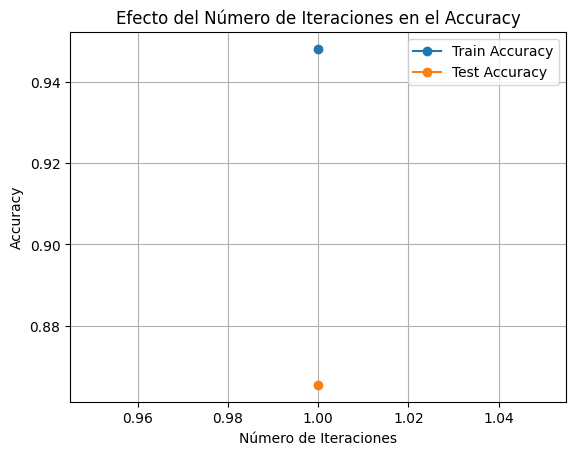

In [182]:
# disable warning
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler

num_iteraciones = 1
# Probar con distintos números de iteraciones
acc_test = []
acc_train = []

for it in range(1, num_iteraciones + 1):
    clf = SGDClassifier(loss="hinge", max_iter=it, random_state=42)
    clf.fit(X_train_flat, y_train)
    y_pred = clf.predict(X_test_flat)

    test_accuracy = accuracy_score(y_test, y_pred)
    train_accuracy = accuracy_score(y_train, clf.predict(X_train_flat))

    acc_test.append(test_accuracy)
    acc_train.append(train_accuracy)

fig = plt.figure()
plt.plot(range(1, num_iteraciones + 1), acc_train, label="Train Accuracy", marker='o')
plt.plot(range(1, num_iteraciones + 1), acc_test, label="Test Accuracy", marker='o')
plt.xlabel("Número de Iteraciones")
plt.ylabel("Accuracy")
plt.title("Efecto del Número de Iteraciones en el Accuracy")
plt.legend()
plt.grid()
plt.show()

Responda:
* ¿Qué sucede con el accuracy al aumentar el número de iteraciones?
* ¿El efecto se ve en ambos sets de datos?
* ¿Es bueno aumentar el número de iteraciones a 100?


#### **Ejercicio 5** 

En la clasificación de datos medicos el accuracy no es suficiente. Es importante considerar otras métricas como la precisión, el recall y la F1-score, especialmente en conjuntos de datos desbalanceados. Para ello, se propone modificar el código para que calcule y muestre estas métricas utilizando la función `classification_report` de `sklearn`.

Responde:
* ¿Comó es el rendimiento utilizando 100 iteraciones?
* ¿Como se comporta el modelo utilizando 2 iteraciones?
* ¿Qué modelo funciona mejor?
* ¿Existe overfitting?
* Para clasificación binaria, ¿Que implica un rendimiento del 50% en el accuracy?




In [183]:
# <CODE>
from sklearn.metrics import classification_report

clf = SGDClassifier(loss="hinge", max_iter=100, random_state=42)
clf.fit(X_train_flat, y_train)
y_pred = clf.predict(X_test_flat)

# Mostrar métricas de clasificación
print(classification_report(y_test, y_pred))

clf = SGDClassifier(loss="hinge", max_iter=2, random_state=42)
clf.fit(X_train_flat, y_train)
y_pred = clf.predict(X_test_flat)

# Mostrar métricas de clasificación
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84       234
           1       0.88      0.94      0.91       390

    accuracy                           0.88       624
   macro avg       0.88      0.86      0.87       624
weighted avg       0.88      0.88      0.88       624

              precision    recall  f1-score   support

           0       0.95      0.63      0.76       234
           1       0.81      0.98      0.89       390

    accuracy                           0.85       624
   macro avg       0.88      0.81      0.82       624
weighted avg       0.87      0.85      0.84       624



/opt/anaconda3/envs/diplomado/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


#### **Ejercicio**

Resulta importante visualizar en que categorias se producen los errores de clasificacion. Para ello, se propone modificar el código para que genere una matriz de confusión y un informe de clasificación utilizando la función `ConfusionMatrixDisplay` de `sklearn`. Realice el plot de la matriz de confusión absoluta y normalizada


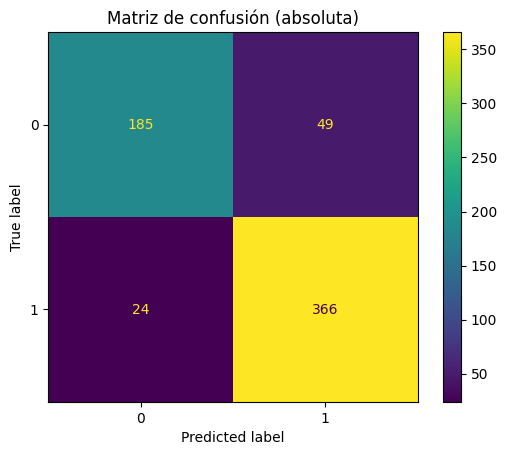

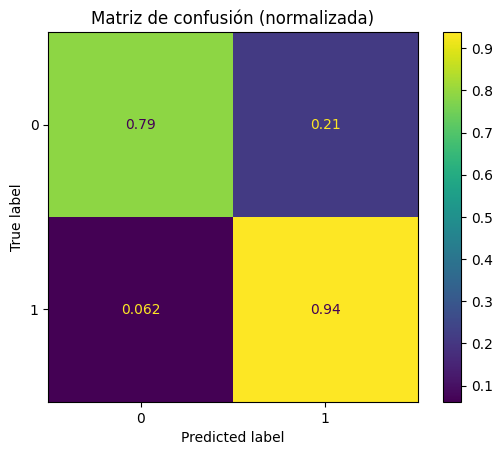

In [ ]:
# <CODE>
from sklearn.metrics import ConfusionMatrixDisplay

clf = SGDClassifier(loss="hinge", random_state=42)
clf.fit(X_train_flat, y_train)

y_pred = clf.predict(X_test_flat)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Matriz de confusión (absoluta)')
plt.show()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true')
plt.title('Matriz de confusión (normalizada)')
plt.show()